Renaming 'valid_time' to 'time'...
Data loaded successfully.
Data Dimensions: FrozenMappingWarningOnValuesAccess({'time': 360, 'latitude': 181, 'longitude': 281})


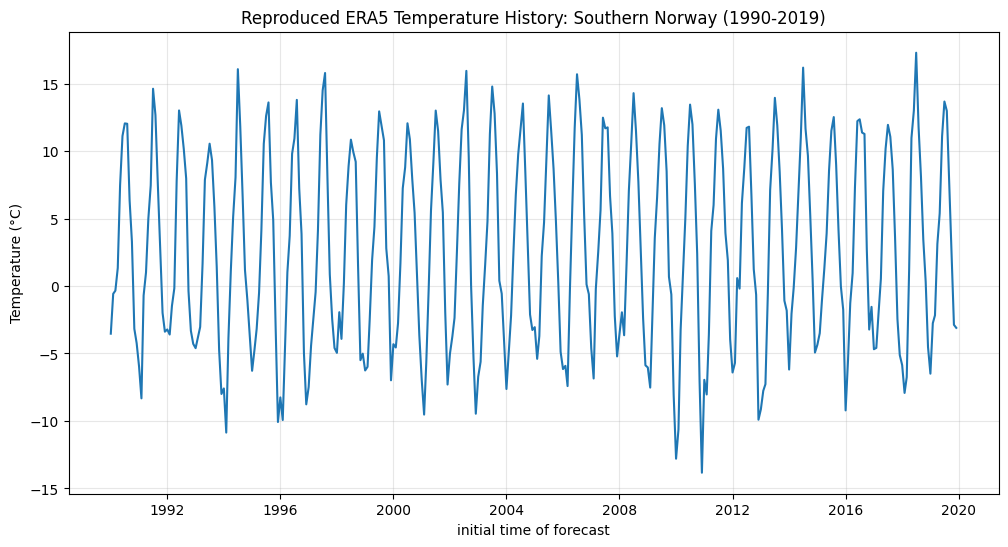

Weather data processed and saved to '../data/processed/norway_weather_clean.csv'.
   year  temperature
0  1990     3.479851
1  1991     2.555285
2  1992     2.861445
3  1993     1.801168
4  1994     1.916392


In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Load the "Cube" (Multidimensional Data) ---
file_path = '../data/raw/era5_nordic_temp.nc'

if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
    print("Please run 'src/ingest_data.py' first.")
else:
    ds = xr.open_dataset(file_path)

    # --- THE FIX: Handle the "valid_time" vs "time" naming issue ---
    if 'valid_time' in ds.dims:
        print("Renaming 'valid_time' to 'time'...")
        ds = ds.rename({'valid_time': 'time'})
    
    # Show the "0.1%" insight: Explicitly mention dimensions
    print("Data loaded successfully.")
    print(f"Data Dimensions: {ds.dims}") 

    # --- 2. The "Masking" Challenge ---
    # Approximate Bounding Box for Southern Norway (Population Center)
    # Lat: 58-62, Lon: 5-12
    norway_subset = ds.sel(latitude=slice(62, 58), longitude=slice(5, 12))

    # --- 3. The Aggregation (Reduce Dimensions) ---
    # We calculate the mean temperature over the area for each month
    # This collapses (Lat, Lon) -> Time
    # 't2m' is the variable name for "2 metre temperature" in ERA5
    # Note: Sometimes the variable is also named differently, we check for that:
    var_name = 't2m' if 't2m' in ds else '2m_temperature'
    
    norway_temp = norway_subset[var_name].mean(dim=['latitude', 'longitude'])

    # Convert Kelvin to Celsius (Essential domain knowledge check!)
    norway_temp_c = norway_temp - 273.15

    # --- 4. Visualize (The "Result") ---
    plt.figure(figsize=(12, 6))
    norway_temp_c.plot()
    plt.title("Reproduced ERA5 Temperature History: Southern Norway (1990-2019)")
    plt.ylabel("Temperature (°C)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 5. Export for Modeling ---
    # Convert this xarray Series to a Pandas DataFrame for the Bayesian model in Notebook 02
    df_weather = norway_temp_c.to_dataframe(name='temperature').reset_index()
    
    # Extract just Year/Month or Year for merging
    # Now that we renamed it to 'time' above, this line will work
    df_weather['year'] = df_weather['time'].dt.year
    
    # We aggregate to Yearly average to match the GBD data structure
    df_yearly = df_weather.groupby('year')['temperature'].mean().reset_index()

    # Create directory if it doesn't exist
    os.makedirs('../data/processed', exist_ok=True)
    
    df_yearly.to_csv('../data/processed/norway_weather_clean.csv', index=False)
    print("Weather data processed and saved to '../data/processed/norway_weather_clean.csv'.")
    print(df_yearly.head())